In [1]:
# =============================================================================
# STEP 1: LIBRARY IMPORTS & SETUP
# Purpose: Import necessary tools for Machine Learning and data manipulation.
# =============================================================================
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Display setup to ensure we can see all columns when previewing data
pd.set_option('display.max_columns', None)
print("✅ Cell 1 Complete: Libraries Imported Successfully.")

✅ Cell 1 Complete: Libraries Imported Successfully.


In [2]:
# =============================================================================
# STEP 2: DATA LOADING & PREPARATION
# Purpose: Load the clean dataset and define the features and target variable.
# =============================================================================
file_path = 'Final_Stacked_ML_Input_CLEAN.csv'
print(f"📂 Loading dataset: {file_path}...")

try:
    df = pd.read_csv(file_path)
    print(f"   -> Data Loaded Successfully. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
except FileNotFoundError:
    print(f"❌ ERROR: File '{file_path}' not found. Please upload it to the directory.")

# Define Target and Features
# TARGET: 'logFC' (Chosen because it represents the biological magnitude of change)
target_col = 'logFC'

# FEATURES: All other statistical metrics (excluding Gene.Symbol and Dataset_ID)
feature_cols = ['AveExpr', 't', 'P.Value', 'adj.P.Val', 'B']

print(f"🎯 Target Variable: {target_col}")
print(f"📊 Features used for prediction: {feature_cols}")

📂 Loading dataset: Final_Stacked_ML_Input_CLEAN.csv...
   -> Data Loaded Successfully. Shape: 70920 rows, 8 columns.
🎯 Target Variable: logFC
📊 Features used for prediction: ['AveExpr', 't', 'P.Value', 'adj.P.Val', 'B']


In [3]:
# =============================================================================
# STEP 3: FEATURE SCALING & MODEL TRAINING
# Purpose: Scale the data and train the Random Forest Regressor (our best model).
# =============================================================================
# Extract X (Features) and y (Target)
X = df[feature_cols]
y = df[target_col]

# Handle any potential missing values by filling them with the column mean
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())

# Scale features to ensure uniform influence during training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("🚀 Training Random Forest Model on the entire dataset...")
# Initialize Random Forest (n_jobs=-1 uses all computer cores for faster processing)
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

# Fit the model
rf_model.fit(X_scaled, y)
print("✅ Cell 3 Complete: Model Training Finished.")

🚀 Training Random Forest Model on the entire dataset...
✅ Cell 3 Complete: Model Training Finished.


In [4]:
# =============================================================================
# STEP 4: BIOMARKER EXTRACTION (PREDICTION & SCORING)
# Purpose: Predict the logFC for every gene and calculate the "Impact Score".
# =============================================================================
print("🧬 Scoring all genes to find the Top Biomarkers...")

# 1. Use the trained AI to predict the logFC for every row
df['Predicted_logFC'] = rf_model.predict(X_scaled)

# 2. Calculate the ML Impact Score (Absolute Predicted logFC)
# We use the absolute value because extreme UP-regulation (+) and extreme
# DOWN-regulation (-) are equally critical as biological markers.
df['ML_Impact_Score'] = df['Predicted_logFC'].abs()

# 3. Group the data by Gene Symbol to find their consistent average score
biomarkers = df.groupby('Gene.Symbol').agg(
    ML_Impact_Score=('ML_Impact_Score', 'mean'),
    Actual_logFC=('logFC', 'mean')
).reset_index()

print("✅ Cell 4 Complete: Genes have been scored successfully.")

🧬 Scoring all genes to find the Top Biomarkers...
✅ Cell 4 Complete: Genes have been scored successfully.


In [5]:
# =============================================================================
# STEP 5: RANKING, CLASSIFICATION, & EXPORTING
# Purpose: Extract the Top 50, classify their regulation status, and save to CSV.
# =============================================================================
# 1. Sort the genes by their ML Impact Score (Highest to Lowest)
top_50 = biomarkers.sort_values(by='ML_Impact_Score', ascending=False).head(50)

# 2. Add Biological Classification (Cancer Driver vs. Tumor Suppressor)
# If the actual logFC is positive, it is Upregulated. If negative, Downregulated.
top_50['Regulation Status'] = top_50['Actual_logFC'].apply(
    lambda x: "Upregulated (Cancer Driver)" if x > 0 else "Downregulated (Tumor Suppressor)"
)

# 3. Add a Ranking Column (1 to 50)
top_50.insert(0, 'Rank', range(1, 51))

# 4. Preview the Top 5
print("\n🏆 TOP 5 PREDICTED BIOMARKERS 🏆")
print("="*70)
print(top_50[['Rank', 'Gene.Symbol', 'ML_Impact_Score', 'Regulation Status']].head(5))
print("="*70)

# 5. Save to a final CSV file
output_filename = 'Top_50_ML_Biomarkers.csv'
top_50.to_csv(output_filename, index=False)

print(f"\n🎉 SUCCESS! The Top 50 Biomarkers have been saved to '{output_filename}'")


🏆 TOP 5 PREDICTED BIOMARKERS 🏆
       Rank Gene.Symbol  ML_Impact_Score                 Regulation Status
2823      1     CYP2B7P          1.49080       Upregulated (Cancer Driver)
11063     2       SFRP1          1.31888  Downregulated (Tumor Suppressor)
10375     3       ROPN1          1.29440  Downregulated (Tumor Suppressor)
10376     4      ROPN1B          1.29440  Downregulated (Tumor Suppressor)
4371      5       GABRP          1.28064  Downregulated (Tumor Suppressor)

🎉 SUCCESS! The Top 50 Biomarkers have been saved to 'Top_50_ML_Biomarkers.csv'


📊 Generating Figure 2: Top 50 Predictive Biomarkers Bar Chart...


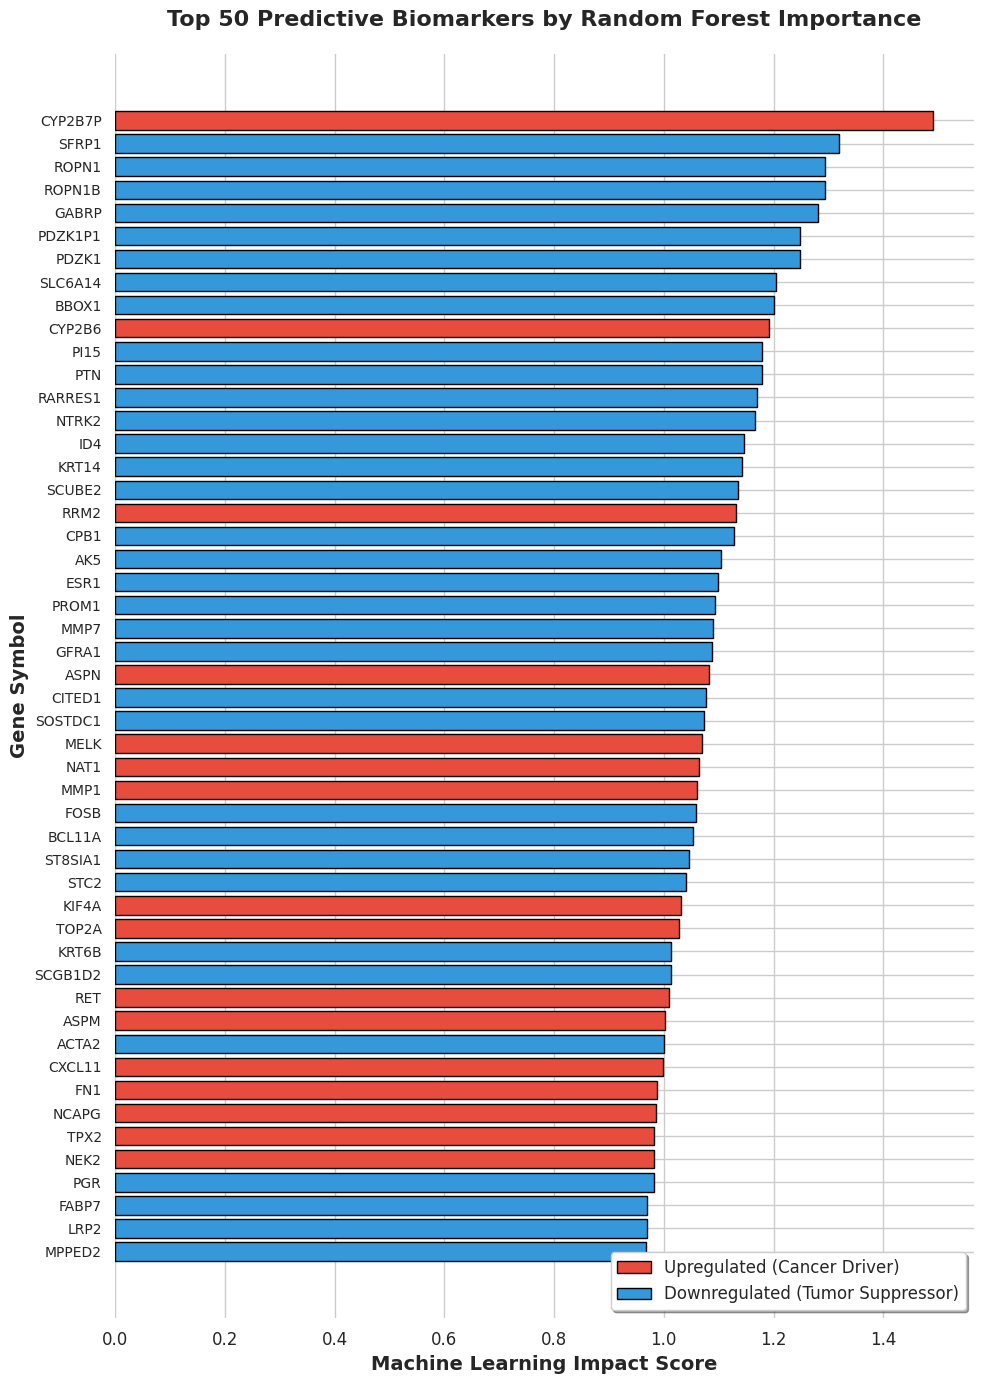


✅ SUCCESS! Your bar chart has been saved as 'Figure_2_Top_50_Biomarkers.png' in your folder.
You can now insert this image directly into your MS Word document for Figure 2.


In [6]:
# =============================================================================
# STEP 6: DATA VISUALIZATION (FIGURE 2)
# Purpose: Generate and save a high-quality bar chart of the Top 50 Biomarkers.
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generating Figure 2: Top 50 Predictive Biomarkers Bar Chart...")

# 1. Sort the data from lowest to highest so the highest value is at the top of the chart
plot_data = top_50.sort_values(by='ML_Impact_Score', ascending=True)

# 2. Set the aesthetic style of the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 14)) # Tall enough to fit all 50 genes comfortably

# 3. Define colors based on Regulation Status (Red for Upregulated, Blue for Downregulated)
colors = ['#e74c3c' if val == 'Upregulated (Cancer Driver)' else '#3498db'
          for val in plot_data['Regulation Status']]

# 4. Create the horizontal bar plot
bars = plt.barh(plot_data['Gene.Symbol'], plot_data['ML_Impact_Score'], color=colors, edgecolor='black')

# 5. Add titles and labels with professional formatting
plt.title('Top 50 Predictive Biomarkers by Random Forest Importance', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Machine Learning Impact Score', fontsize=14, fontweight='bold')
plt.ylabel('Gene Symbol', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)

# 6. Add a custom legend to explain the colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', edgecolor='black', label='Upregulated (Cancer Driver)'),
                   Patch(facecolor='#3498db', edgecolor='black', label='Downregulated (Tumor Suppressor)')]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True, shadow=True)

# 7. Remove top and right borders for a cleaner, academic look
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 8. Save the figure as a high-resolution image for your Word Document
image_filename = "Figure_2_Top_50_Biomarkers.png"
plt.savefig(image_filename, dpi=300, bbox_inches='tight')

# 9. Display the plot in the notebook
plt.show()

print(f"\n✅ SUCCESS! Your bar chart has been saved as '{image_filename}' in your folder.")
print("You can now insert this image directly into your MS Word document for Figure 2.")